# Encoder Pretraining

Runs `Pretrainer.run()` to initialize the `GraphormerNRIEncoder` to output the prior edge-type distribution before RL training starts.

**Sections**
1. Run pretraining and record per-epoch KL loss + wall-clock time.
2. Plot training curves (loss & duration per epoch).
3. Compare the final encoder posterior against the prior using N×N heatmaps (one cell per node pair (i,j), color = P(edge exists)).

In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import torch.nn.functional as F

REPO_ROOT = Path("/home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids").resolve()
os.chdir(REPO_ROOT)
for p in [str(REPO_ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from grid2op.gym_compat import GymEnv
from grid2op_env.observation_converter import EDGE_INDEX, EDGE_MASK, NODES, make_observation_converter
from grid2op_env.utils import make_g2op_env
from rarl import GraphormerNRIEncoder, fully_connected_edge_index, get_prior_tensor
from rarl.prior import get_priors
from core.pretraining import Pretrainer

plt.style.use("default")

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-03 17:24:23,220	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-03 17:24:23,506	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# ── Environment ─────────────────────────────────────────────────────────────────
ENV_CONFIG = {
    "env_name":         "l2rpn_case14_sandbox",
    "grid2op_kwargs":   {},
    "observation_space": "GraphObsSpace",
}

# ── Encoder (matches production ragnn.yaml defaults) ────────────────────────────
X_DIM              = 7    # _DEFAULT_NODE_FEATURES in observation_converter.py
HIDDEN_DIM         = 64
NUM_LAYERS         = 2
NUM_ATTENTION_HEADS = 2
NUM_EDGE_TYPES     = 2    # relation_awareness/default.yaml → latent_space.num_edge_types
MAX_DEGREE         = 20   # ragnn.yaml → encoder.max_degree
MAX_PATH_DISTANCE  = 50   # ragnn.yaml → encoder.max_path_distance

# ── Pretraining ─────────────────────────────────────────────────────────────────
NUM_OBSERVATIONS = 200   # environment steps to sample
NUM_EPOCHS       = 20    # training epochs over the dataset
LR               = 1e-3
BETA             = 0.4   # KL weight for powerline edges  (matches beta_graph_edges_end)
BETA_NON_GRAPH   = 0.4   # KL weight for latent edges
PRIOR_PROB       = 0.9   # prior_prob_for_graph_edge
TEMPERATURE      = 0.5   # prior temperature

## Run Pretraining

In [3]:
encoder = GraphormerNRIEncoder(
    x_dim=X_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    num_edge_types=NUM_EDGE_TYPES,
    max_degree=MAX_DEGREE,
    max_path_distance=MAX_PATH_DISTANCE,
)

pretrainer = Pretrainer(
    env_config=ENV_CONFIG,
    prior_prob_for_graph_edge=PRIOR_PROB,
    temperature=TEMPERATURE,
    num_edge_types=NUM_EDGE_TYPES,
    beta=BETA,
    beta_non_graph=BETA_NON_GRAPH,
    lr=LR,
    verbose=True,
)

results = pretrainer.run(encoder, num_observations=NUM_OBSERVATIONS, num_epochs=NUM_EPOCHS)
print(f"\nFinal epoch loss : {results.losses_per_epoch[-1]:.4f}")
print(f"Total time       : {sum(results.time_ms_per_epoch)/1000:.1f} s")

Train 20 epochs: 100%|██████████| 20/20 [01:50<00:00,  5.54s/it]


Final epoch loss : 0.0002
Total time       : 110.8 s


## Training Curves

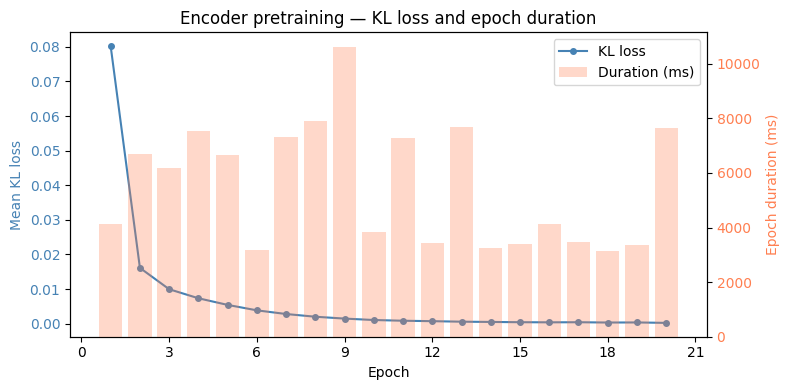

In [4]:
epochs = np.arange(1, NUM_EPOCHS + 1)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(epochs, results.losses_per_epoch, color="steelblue", marker="o", markersize=4, label="KL loss")
ax2.bar(epochs, results.time_ms_per_epoch, alpha=0.3, color="coral", label="Duration (ms)")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Mean KL loss", color="steelblue")
ax2.set_ylabel("Epoch duration (ms)", color="coral")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="coral")
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Encoder pretraining — KL loss and epoch duration")
fig.tight_layout()
plt.show()

## Prior & Posterior Distributions

Sample one observation from the environment, compute the prior from its topology,
and run the trained encoder to obtain the posterior. Both are then mapped to an
N×N matrix where entry (i,j) holds P(edge i→j exists).

In [5]:
# ── Sample one observation ───────────────────────────────────────────────────────
env_g2op = make_g2op_env(ENV_CONFIG)
env_gym  = GymEnv(env_g2op, with_forecast=True)
obs_conv = make_observation_converter(env_gym, ENV_CONFIG)

g2op_obs = env_g2op.reset()
gym_obs  = obs_conv.to_gym(g2op_obs)

x               = torch.from_numpy(gym_obs[NODES]).float()       # [N, x_dim]
ei_padded       = gym_obs[EDGE_INDEX]                            # [2, max_E]
mask            = gym_obs[EDGE_MASK]                             # [max_E]
powerline_edges = torch.from_numpy(ei_padded[:, mask]).long()    # [2, E']
n_line, n_gen   = env_g2op.n_line, env_g2op.n_gen               # save before close
env_g2op.close()

N         = x.shape[0]
all_edges = fully_connected_edge_index(N)                        # [2, E_fc]
E_fc      = all_edges.shape[1]
print(f"Nodes N={N},  FC edges E_fc={E_fc},  powerline edges={powerline_edges.shape[1]}")

# ── Prior ───────────────────────────────────────────────────────────────────────
num_graph     = powerline_edges.shape[1]
num_non_graph = E_fc - num_graph
g_prior, ng_prior = get_priors(
    prob_graph_edges_exist=PRIOR_PROB,
    num_graph_edges=num_graph,
    num_non_graph_edges=num_non_graph,
    temperature=TEMPERATURE,
)
prior_tensor, graph_mask = get_prior_tensor(
    graph_edges=powerline_edges,
    all_edges=all_edges,
    prior_for_graph_edges=g_prior,
    prior_for_non_graph_edges=ng_prior,
    num_edge_types=NUM_EDGE_TYPES,
    return_mask=True,
)  # prior_tensor: [E_fc, K]

# ── Posterior ───────────────────────────────────────────────────────────────────
encoder.eval()
with torch.no_grad():
    logits    = encoder(x=x, powerline_edge_index=powerline_edges)  # [E_fc, K]
    posterior = F.softmax(logits, dim=-1)                           # [E_fc, K]

# ── Map to N×N matrices (P(edge exists) = index 0) ──────────────────────────────
src, dst = all_edges[0].numpy(), all_edges[1].numpy()

prior_map = np.zeros((N, N))
prior_map[src, dst] = prior_tensor[:, 0].numpy()

posterior_map = np.zeros((N, N))
posterior_map[src, dst] = posterior[:, 0].numpy()

print(f"Prior    — graph edges mean: {prior_tensor[graph_mask, 0].mean():.3f},  "
      f"latent edges mean: {prior_tensor[~graph_mask, 0].mean():.3f}")
print(f"Posterior— graph edges mean: {posterior[graph_mask, 0].mean():.3f},  "
      f"latent edges mean: {posterior[~graph_mask, 0].mean():.3f}")

Nodes N=57,  FC edges E_fc=3192,  powerline edges=244
Prior    — graph edges mean: 0.900,  latent edges mean: 0.050
Posterior— graph edges mean: 0.901,  latent edges mean: 0.051


/tmp/ipykernel_47751/4025606568.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


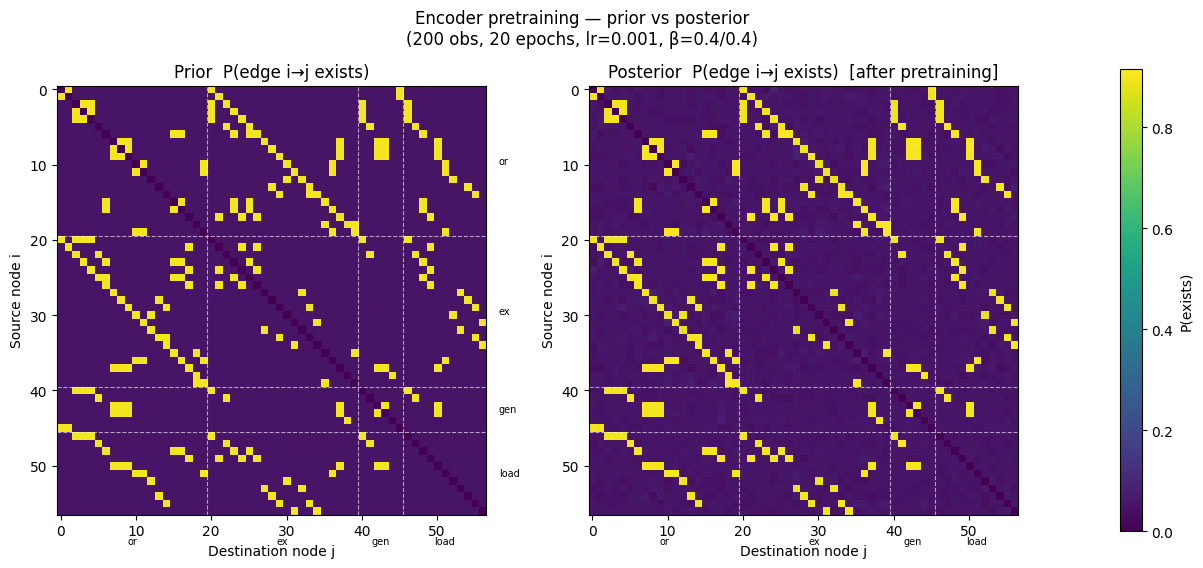

In [6]:
# ── Node-type boundaries for annotation ─────────────────────────────────────────
bounds = [n_line, 2 * n_line, 2 * n_line + n_gen]   # [or|ex, ex|gen, gen|load]
type_labels = ["or", "ex", "gen", "load"]

def _annotate_boundaries(ax, bounds, labels, n, show_y=True):
    """Dashed boundary lines + region labels placed in axes-fraction coordinates."""
    positions = [0] + bounds + [n]
    for b in bounds:
        ax.axhline(b - 0.5, color="white", lw=0.8, ls="--", alpha=0.6)
        ax.axvline(b - 0.5, color="white", lw=0.8, ls="--", alpha=0.6)
    for k, label in enumerate(labels):
        x_frac = (positions[k] + positions[k + 1]) / 2 / n          # fraction along x
        y_frac = 1.0 - (positions[k] + positions[k + 1]) / 2 / n    # fraction along y (image y=0 is top)
        # Below the x-axis
        ax.text(x_frac, -0.05, label, ha="center", va="top", fontsize=7,
                transform=ax.transAxes, clip_on=False)
        # Right of the y-axis (only on the left subplot to avoid overlap with colorbar)
        if show_y:
            ax.text(1.03, y_frac, label, ha="left", va="center", fontsize=7,
                    transform=ax.transAxes, clip_on=False)

# ── Prior vs Posterior side-by-side ─────────────────────────────────────────────
vmax = max(prior_map.max(), posterior_map.max())

fig, axes = plt.subplots(1, 3, figsize=(14, 6),
                         gridspec_kw={"width_ratios": [1, 1, 0.05], "wspace": 0.35})
ax_prior, ax_post, ax_cb = axes

# aspect="equal" (default for imshow) keeps each cell square
im_kw = dict(vmin=0, vmax=vmax, cmap="viridis", interpolation="nearest")

ax_prior.imshow(prior_map, **im_kw)
ax_prior.set_title("Prior  P(edge i→j exists)")
ax_prior.set_xlabel("Destination node j")
ax_prior.set_ylabel("Source node i")
_annotate_boundaries(ax_prior, bounds, type_labels, N, show_y=True)

im2 = ax_post.imshow(posterior_map, **im_kw)
ax_post.set_title("Posterior  P(edge i→j exists)  [after pretraining]")
ax_post.set_xlabel("Destination node j")
ax_post.set_ylabel("Source node i")
_annotate_boundaries(ax_post, bounds, type_labels, N, show_y=False)

fig.colorbar(im2, cax=ax_cb, label="P(exists)")
fig.suptitle(
    f"Encoder pretraining — prior vs posterior\n"
    f"({NUM_OBSERVATIONS} obs, {NUM_EPOCHS} epochs, lr={LR}, β={BETA}/{BETA_NON_GRAPH})",
    fontsize=12,
)
fig.tight_layout()
plt.show()